# Exploring Financial Data Using the Nasdaq Data Link API

## Introduction

### API Description

The Nasdaq Data Link API provides access to a wide range of financial datasets. The API will be used to retreive detailed financial information including balance sheets, cash flow statements and income statements from the `MER/F1` data table.

With a view to exploring how financial metrics differ among companies and regions.

Analysis will focus on the Accrued Expenses Turnover metric. This is a measure of a company's financial health and how it manages its debt. It shows how quickly a company pays off its accrued liabilities.

### Project Goal

Perform a detailed analysis using Python to retrieve, clean, analyse and visualise the data to explore the Accrued Expenses Turnover metric for various companies and regions, focusing on the time perido from 2011 to 2015.

### Import Required Libraries and Packages

In [1]:
import config
import requests
import pandas as pd
import matplotlib.pyplot as plt

## API Documentation and Credentials

Please refer to the [API usage documentation](https://docs.data.nasdaq.com/docs/in-depth-usage-1) for reference.

In [2]:
# API Security and Constant Declarations
API_KEY = config.API_KEY

# Base URL
url = 'https://data.nasdaq.com/api/v3/datatables/MER/F1.json'

# Dictionary of API Parameters
parameters = {
    'api_key': API_KEY,
    'qopts.per_page': 1  # Number of rows to fetch
}

## Working with the Endpoint and Parameters to Query the API

Retrieve a small amount of data from the API to understand the output and how to get the output into a DataFrame.

In [3]:
# Fetch data in Json format
json_data = requests.get(url, params=parameters).json()
print(json_data)

{'datatable': {'data': [[2438, 1868192544, -1802, 10.481948, '2011-06-30', 'Q2', 'U', 'EUR', 'True', 'Deutsche Bank AG', 'Deutsche Bank AG', 'Active', 'DEU', 'Europe', 1159508, '5.1.1', 'DB', 'NYS', 'Taunusanlage 12', None, None, None, 'Frankfurt am Main', None, 'DEU', '60325', '(49) 69 910 00', '(49) 69 910 34 225', 'www.db.com', '2024-12-31', 'Accrued Expenses Turnover', 'Derived']], 'columns': [{'name': 'compnumber', 'type': 'Integer'}, {'name': 'reportid', 'type': 'Integer'}, {'name': 'mapcode', 'type': 'Integer'}, {'name': 'amount', 'type': 'BigDecimal(36,14)'}, {'name': 'reportdate', 'type': 'Date'}, {'name': 'reporttype', 'type': 'String'}, {'name': 'auditorstatus', 'type': 'String'}, {'name': 'currency', 'type': 'String'}, {'name': 'consolidated', 'type': 'String'}, {'name': 'longname', 'type': 'String'}, {'name': 'shortname', 'type': 'String'}, {'name': 'status', 'type': 'String'}, {'name': 'countrycode', 'type': 'String'}, {'name': 'region', 'type': 'String'}, {'name': 'cik',

## Processing the JSON Data into a DataFrame

In [4]:
# Extract column names from the 'name' values in the 'columns' values
column_names = [x['name'] for x in json_data['datatable']['columns']]

In [5]:
# Create DataFrame from the 'data' values along with the previously extracted column names
df = pd.DataFrame(json_data['datatable']['data'], columns=column_names)
df

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived


In [6]:
# Increase the 'qopts.per_page' parameter to retrieve 10,000 records
parameters['qopts.per_page'] = 10000

# Call the API to retrieve the new dataset
json_data = requests.get(url, params=parameters).json()

# Redefine the column names
column_names = [x['name'] for x in json_data['datatable']['columns']]

# Create the DataFrame
df_metric = pd.DataFrame(json_data['datatable']['data'], columns=column_names)

# Show the first few rows of the new DataFrame
df_metric.head()

,compnumber,reportid,mapcode,amount,reportdate,reporttype,auditorstatus,currency,consolidated,longname,...,city,statecode,country,zipcode,phonenumber,faxnumber,website,fye,indicator,statement
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,U,EUR,True,Deutsche Bank AG,...,Frankfurt am Main,None,DEU,60325,(49) 69 910 00,(49) 69 910 34 225,www.db.com,2024-12-31,Accrued Expenses Turnover,Derived


## Understanding the Dataset

In [7]:
df_metric.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   compnumber     10000 non-null  int64  
 1   reportid       10000 non-null  int64  
 2   mapcode        10000 non-null  int64  
 3   amount         10000 non-null  float64
 4   reportdate     10000 non-null  object 
 5   reporttype     10000 non-null  object 
 6   auditorstatus  9999 non-null   object 
 7   currency       10000 non-null  object 
 8   consolidated   10000 non-null  object 
 9   longname       10000 non-null  object 
 10  shortname      10000 non-null  object 
 11  status         10000 non-null  object 
 12  countrycode    10000 non-null  object 
 13  region         10000 non-null  object 
 14  cik            10000 non-null  int64  
 15  mic            10000 non-null  object 
 16  ticker         9380 non-null   object 
 17  exchange       10000 non-null  object 
 18  address

Exclude columns that will not add anything useful to the analysis, for example, the address details and contact numbers.

The remaining columns will allows us to analyse trends and make regional comparisons.

In [8]:
necessary_columns = [
    'compnumber',
    'reportid',
    'mapcode',
    'amount',
    'reportdate',
    'reporttype',
    'currency',
    'longname',
    'city',
    'country',
    'indicator',
    'statement'
]

## Filtering the DataFrame for Analysis

Filter the DataFrame for the selected columns and where the `indicator` value is 'Accrued Expenses Turnover' as this is where the analysis is to be focused.

In [9]:
df_metric = df_metric[necessary_columns]

In [10]:
filtered_df = df_metric[df_metric['indicator'] == 'Accrued Expenses Turnover']

Use `df.describe()` to inspect the statistics of the new dataset

In [11]:
filtered_df.describe()

,compnumber,reportid,mapcode,amount
count,139.000000,1.390000e+02,139.0,139.000000
mean,68292.302158,1.633594e+09,-1802.0,26.908762
std,53272.892697,1.385283e+08,0.0,33.097291
min,1409.000000,1.504051e+09,-1802.0,4.689773
25%,12161.000000,1.543963e+09,-1802.0,9.675670
50%,104579.000000,1.581646e+09,-1802.0,13.753753
75%,111113.000000,1.622541e+09,-1802.0,31.777614
max,133772.000000,1.952498e+09,-1802.0,229.810427


`mapcode` looks to be a code associated with this particular metric.

The `max` amount of 229.8 looks like it could be an outlier whilst there is quite a large standard deviation.

## Enhancing the DataFrame

Create a `country` column that will contain the full names of the countries from the country codes.

In [12]:
filtered_df['country'].unique()

array(['DEU', 'BHS', 'GBR', 'JPN', 'CYM', 'USA', 'IRL'], dtype=object)

In [13]:
def get_country(country_code):
    country_mapping = {
        'USA': 'United States of America',
        'DEU': 'Germany',
        'JPN': 'Japan',
        'CYM': 'Cayman Islands',
        'BHS': 'Bahamas',
        'IRL': 'Ireland',
        'GBR': 'Great Britain'
    }
    return country_mapping[country_code]

In [39]:
filtered_df.loc[:, 'country_name'] = filtered_df['country'].apply(get_country)

In [15]:
filtered_df.head()

,compnumber,reportid,mapcode,amount,reportdate,reporttype,currency,longname,city,country,indicator,statement,country_name
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany


In [16]:
clean_column_name_map = {
    'compnumber': 'comp_number',
    'reportid': 'report_id',
    'mapcode': 'map_code',
    'reportdate': 'report_date',
    'reporttype': 'report_type',
    'longname': 'company_name'
}
updated_df = filtered_df.rename(clean_column_name_map, axis=1)
updated_df.head()

,comp_number,report_id,map_code,amount,report_date,report_type,currency,company_name,city,country,indicator,statement,country_name
0,2438,1868192544,-1802,10.481948,2011-06-30,Q2,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
1,2438,1868216112,-1802,8.161754,2011-09-30,Q3,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
2,2438,1885063456,-1802,10.788213,2012-06-30,Q2,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
3,2438,1885087024,-1802,9.437545,2012-09-30,Q3,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany
4,2438,1901934112,-1802,8.755041,2013-06-30,Q2,EUR,Deutsche Bank AG,Frankfurt am Main,DEU,Accrued Expenses Turnover,Derived,Germany


In [17]:
updated_df['country_name'].value_counts()

country_name
United States of America    31
Japan                       27
Cayman Islands              27
Ireland                     25
Bahamas                     19
Germany                      6
Great Britain                4
Name: count, dtype: int64

## Understanding Financial Trends Over Time

Ensure `report_date` is in the correct format and filter the dataset for the period 2010-2015 for trend analysis.

In [18]:
updated_df['report_date'] = pd.to_datetime(updated_df['report_date'])

In [19]:
updated_df = updated_df[(updated_df['report_date'].dt.year >= 2010) & (updated_df['report_date'].dt.year <= 2015)]

Required columns for trend analysis are `company_name`, `report_date` and `amount`.

In [20]:
relevant_data = updated_df[['company_name', 'report_date', 'amount']]

Create a line plot showing how the financial metric changes over time for each individual company.

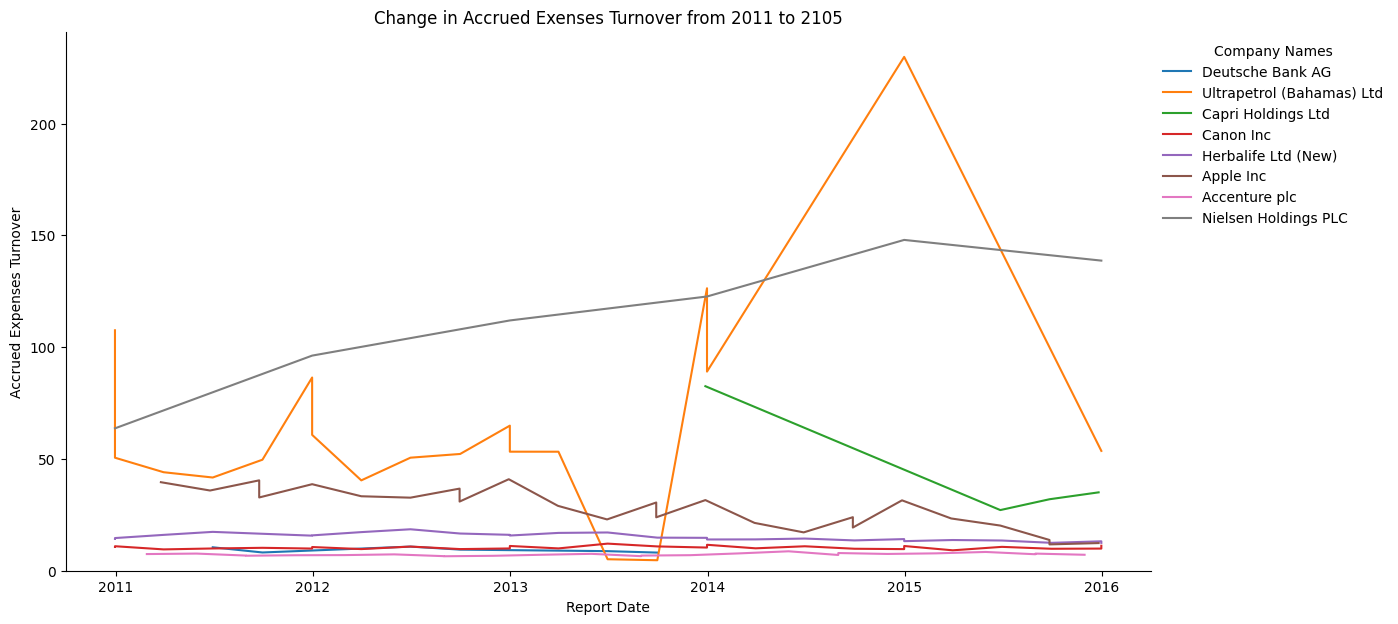

In [32]:
plt.figure(figsize=(14, 7))
for company in relevant_data['company_name'].unique():
    company_data = relevant_data[relevant_data['company_name'] == company]
    plt.plot(company_data['report_date'],
             company_data['amount'],
             label=company)
plt.legend(bbox_to_anchor=(1, 1),
           loc='upper left',
           title='Company Names',
           frameon=False)
plt.xlabel('Report Date')
plt.ylabel('Accrued Expenses Turnover')
plt.title("Change in Accrued Exenses Turnover from 2011 to 2105")
plt.gca().spines[['right', 'top']].set_visible(False)
plt.ylim(ymin=0)
plt.show()

Most of the companies analysed had Accrued Expenses Turnover relatively constant over the period. However, some companies showed extreme variances showing fluctuations in how quickly their debts were paid.

## Geographical Region Analysis

Group the data by region to try to understand regional performance.

In [40]:
country_avg = updated_df.groupby('country_name')['amount'].mean().sort_values(ascending=False)

Create a bar chart to show the average Accrued Expenses Turnover for each region in the dataset.

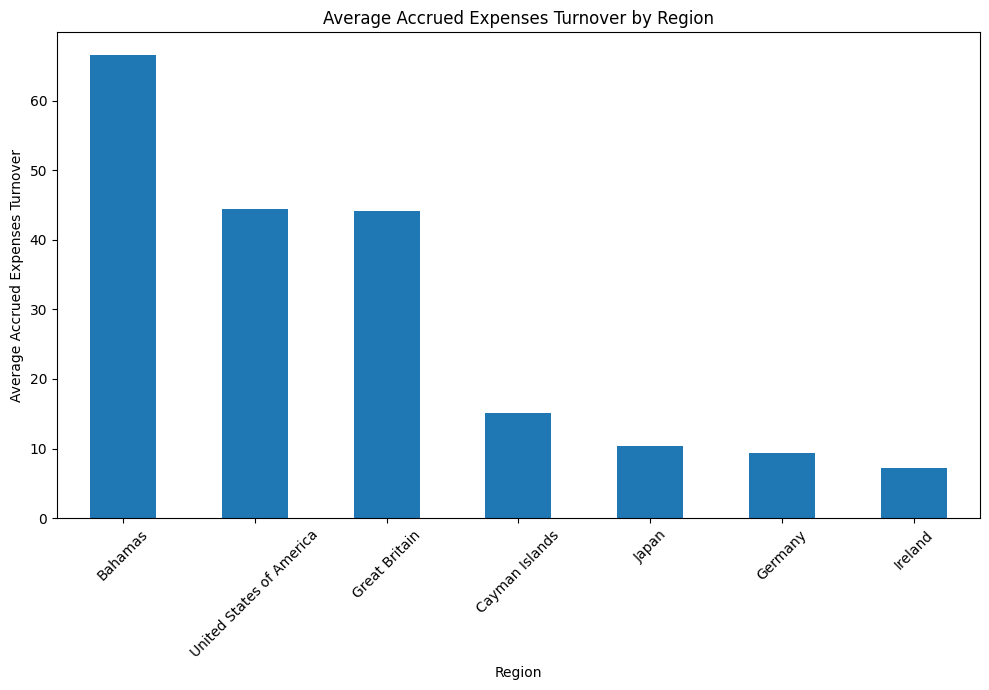

In [41]:
plt.figure(figsize=(10, 7))
country_avg.plot(kind='bar')
plt.title('Average Accrued Expenses Turnover by Region')
plt.xlabel('Region')
plt.ylabel('Average Accrued Expenses Turnover')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Accrued Expenses Turnover was highest in Bahamas. USA and GB were similar to each other with the remainder close together with a much lower average Accrued Expenses Turnover.